# Metric Guide: Which Input Path Should I Use?

TMAP accepts four types of input. This notebook shows each one.

| Your data | Metric | Example |
|-----------|--------|---------|
| Binary fingerprints | `'jaccard'` (default) | Molecular fingerprints |
| Dense float vectors | `'cosine'` or `'euclidean'` | Protein embeddings, image features |
| Distance matrix | `'precomputed'` | Any pairwise distances |
| Already have kNN | `knn_graph=...` | FAISS on GPU, custom pipeline |

## Setup: helper to generate test data

In [5]:
import numpy as np

rng = np.random.default_rng(42)

def make_clustered_binary(n=10_000, d=2048, k=3):
    """Binary fingerprints with k clusters."""
    fp = np.zeros((n, d), dtype=np.uint8)
    labels = []
    for i in range(n):
        c = i % k
        labels.append(f"C{c}")
        fp[i, rng.choice(400, 50, replace=False) + c * 500] = 1
        fp[i, rng.choice(d, 15, replace=False)] = 1
    return fp, labels

def make_clustered_dense(n=10_000, d=128, k=3):
    """Dense float vectors with k clusters."""
    centers = rng.standard_normal((k, d)).astype(np.float32) * 5
    data = np.empty((n, d), dtype=np.float32)
    labels = []
    for i in range(n):
        c = i % k
        labels.append(f"C{c}")
        data[i] = centers[c] + rng.standard_normal(d).astype(np.float32) * 0.5
    return data, labels

print("Helpers ready.")


Helpers ready.


---
## 1. `metric='jaccard'` — Binary fingerprints (default)

Use this when your data is binary (0/1) vectors. TMAP encodes them with
MinHash, indexes with LSH Forest, then builds the tree.

**Typical use cases:** molecular fingerprints (Morgan, MACCS, etc.),
one-hot encoded features, binary bag-of-words.

**No extra dependencies required.**

Embedding: (10000, 2)


<Axes: >

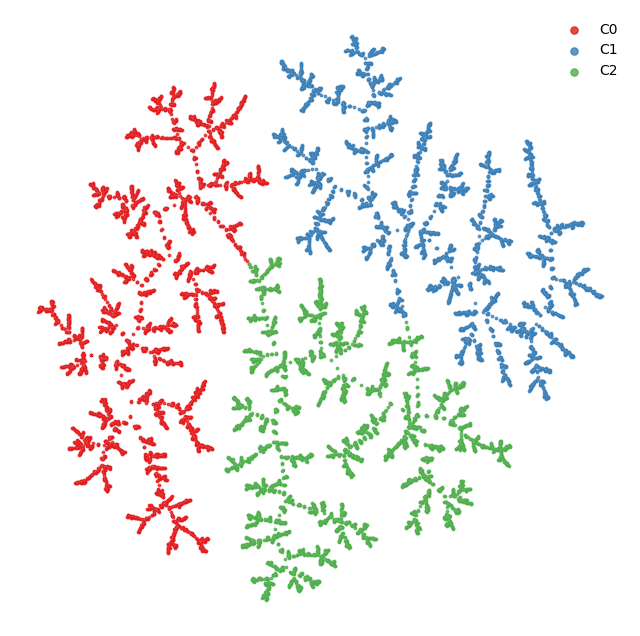

In [17]:
from tmap import TMAP

fp, labels = make_clustered_binary()

model = TMAP(n_neighbors=20, n_permutations=1024,seed=42).fit(fp)  # metric='jaccard' is the default

print(f"Embedding: {model.embedding_.shape}")
model.plot_static(color_by=labels, color_map="Set1", point_size=3)


**Key parameters for Jaccard:**

- `n_permutations` (default 512): MinHash signature length. Higher = more
  accurate Jaccard estimation but slower encoding. 128 is usually enough.
- `kc` (default 10): LSH candidate multiplier. Queries `k * kc` candidates
  then keeps the best `k`. Increase if you get disconnected nodes.

---
## 2. `metric='cosine'` — Dense embeddings (angular similarity)

Use this for dense float vectors where direction matters more than magnitude.

**Typical use cases:** protein embeddings (ESM-2), sentence embeddings,
molecular graph neural network outputs, normalized feature vectors.

**Requires:** `pip install faiss-cpu`

Embedding: (10000, 2)


<Axes: >

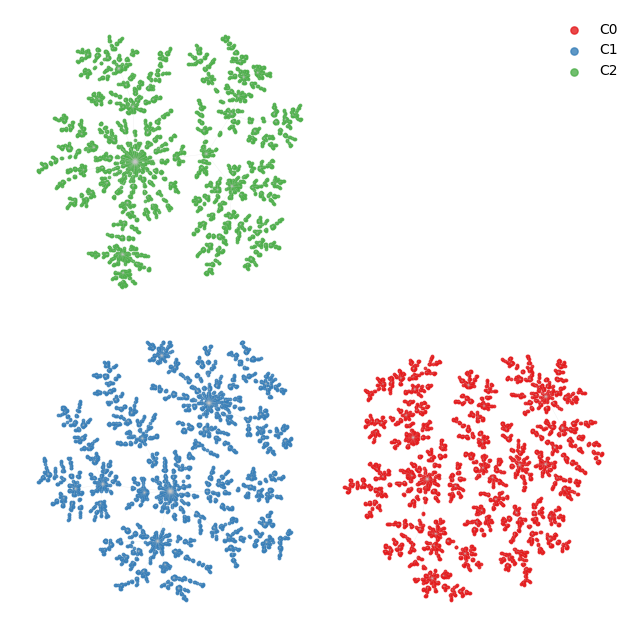

In [19]:
data, labels = make_clustered_dense()

model = TMAP(metric="cosine", n_neighbors=20, seed=42).fit(data)

print(f"Embedding: {model.embedding_.shape}")
model.plot_static(color_by=labels, color_map="Set1", point_size=3)


---
## 3. `metric='euclidean'` — Dense embeddings (L2 distance)

Use this when the magnitude of vectors is meaningful.

**Typical use cases:** PCA-reduced data, physical measurements,
coordinates, any data where L2 distance is the natural metric.

**Requires:** `pip install faiss-cpu`

Embedding: (10000, 2)


<Axes: >

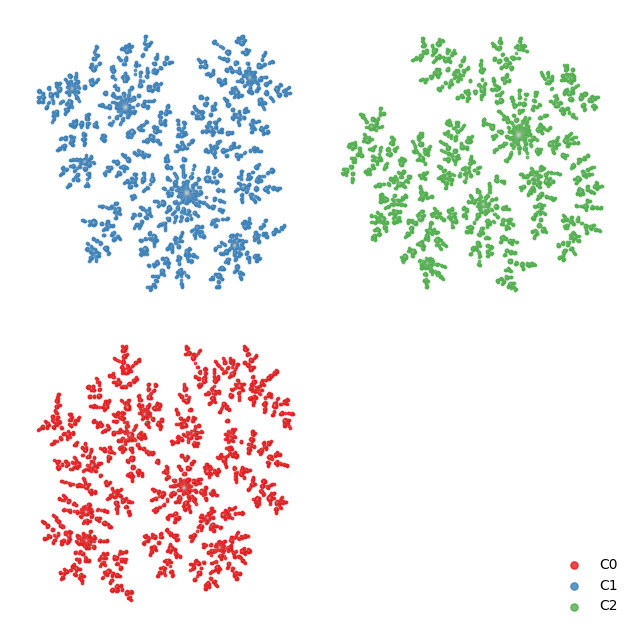

In [12]:
data, labels = make_clustered_dense()

model = TMAP(metric="euclidean", n_neighbors=20, seed=42).fit(data)

print(f"Embedding: {model.embedding_.shape}")
model.plot_static(color_by=labels, color_map="Set1", point_size=3)


### Cosine vs Euclidean: when does it matter?

- If your vectors are **L2-normalized** (unit length), cosine and euclidean
  give the same neighbor ranking. Use either.
- For **unnormalized** embeddings (e.g., raw ESM-2 outputs), cosine ignores
  magnitude and compares only direction. Euclidean considers both.
- Rule of thumb: if your embeddings come from a neural network and you
  haven't normalized them, try **cosine** first.

---
## 4. `metric='precomputed'` — Distance matrix

Use this when you already have pairwise distances and want TMAP to handle
the kNN extraction + layout.

**Typical use cases:** custom distance functions, Tanimoto from external
tools, edit distance, alignment scores converted to distances.

**No extra dependencies required.** Works for small-to-medium datasets
(the distance matrix is n x n, so memory is O(n^2)).

Distance matrix: (10000, 10000)
Embedding: (10000, 2)


<Axes: >

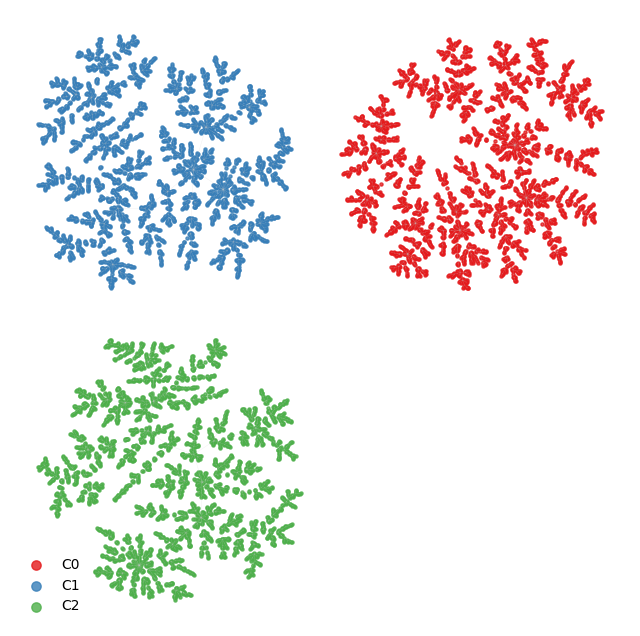

In [14]:
from scipy.spatial.distance import pdist, squareform

data, labels = make_clustered_dense(n=10000, d=32)

# Compute your own distance matrix
dist_matrix = squareform(pdist(data, metric="cosine"))
print(f"Distance matrix: {dist_matrix.shape}")

model = TMAP(metric="precomputed", n_neighbors=15, seed=42).fit(dist_matrix)

print(f"Embedding: {model.embedding_.shape}")
model.plot_static(color_by=labels, color_map="Set1", point_size=5)


---
## 5. `knn_graph=...` — External kNN graph

Use this when you have already computed the kNN graph yourself — e.g.,
with FAISS on a GPU cluster, or from scanpy's `sc.pp.neighbors`.

This skips indexing entirely and goes straight to MST + layout.

**No extra dependencies required.** This is the most flexible path and
scales to millions of points (the kNN graph is sparse: O(n * k)).

Embedding: (2000, 2)


<Axes: >

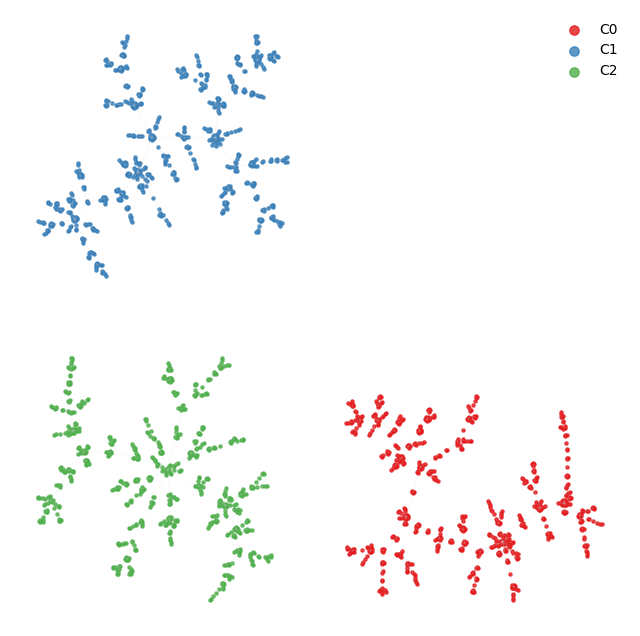

In [15]:
from tmap.index.types import KNNGraph

# Simulate an externally computed kNN (e.g., from FAISS IVFPQ on GPU)
n, k = 2000, 15
data, labels = make_clustered_dense(n=n, d=64)

# Build kNN with scipy as a stand-in for your external tool
from scipy.spatial.distance import cdist
D = cdist(data, data, metric="euclidean").astype(np.float32)
indices = np.argsort(D, axis=1)[:, 1:k+1].astype(np.int32)
distances = np.take_along_axis(D, indices, axis=1)

# Wrap in KNNGraph and pass to TMAP
knn = KNNGraph.from_arrays(indices, distances)
model = TMAP(n_neighbors=k, seed=42).fit(knn_graph=knn)

print(f"Embedding: {model.embedding_.shape}")
model.plot_static(color_by=labels, color_map="Set1", point_size=5)


---
## Decision tree

```
What does your data look like?
|
|-- Binary (0/1) vectors
|   -> metric='jaccard' (default)
|
|-- Dense float vectors
|   |-- Direction matters, not magnitude
|   |   -> metric='cosine'  (pip install faiss-cpu)
|   |-- Both matter
|       -> metric='euclidean'  (pip install faiss-cpu)
|
|-- Already have pairwise distances
|   |-- Small dataset (< ~50k, fits in memory as n x n matrix)
|   |   -> metric='precomputed'
|   |-- Large dataset
|       -> Build kNN externally, use knn_graph=
|
|-- Already have a kNN graph
    -> fit(knn_graph=KNNGraph.from_arrays(indices, distances))
```

## FAISS backend details

For `metric='cosine'` and `metric='euclidean'`, TMAP uses FAISS internally.
The index type is auto-selected based on dataset size:

| Dataset size | Index type | Search |
|-------------|------------|--------|
| < 50,000 | `IndexFlat` | Exact brute-force |
| >= 50,000 | `IndexHNSW` | Approximate (~95%+ recall) |

For datasets larger than what fits on a single machine, build the kNN graph
externally (e.g., FAISS IVFPQ on a GPU cluster) and pass it via `knn_graph=`.